# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз

**Датасет:** Ames Housing Dataset (Kaggle: *House Prices - Advanced Regression Techniques*, отриманий через `sklearn.datasets.fetch_openml(name="house_prices")`, збережений локально у `train.csv`).

**Мета:** реалізувати лінійну регресію та три варіанти градієнтного спуску виключно засобами `numpy`, провести відбір ознак, оцінити якість моделі та перевірити статистичні припущення лінійної регресії.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 5)


## Етап 1. Дослідження даних (EDA), відбір ознак та попередня обробка

### 1.1 Первинний аналіз даних

In [11]:
df = pd.read_csv("train.csv")
print("Розмір датасету:", df.shape)
df.head()


Розмір датасету: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [13]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [14]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Кількість ознак з пропущеними значеннями: {len(missing)} з {df.shape[1]}")
missing.head(20)


Кількість ознак з пропущеними значеннями: 19 з 81


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

**Висновок з первинного аналізу:** датасет містить 1460 об'єктів та 81 ознаку (числові та категоріальні), цільова змінна — `SalePrice`. Деякі ознаки мають дуже велику частку пропусків (наприклад `PoolQC`, `MiscFeature`, `Alley`, `Fence`) — такі ознаки недоцільно використовувати без спеціальної обробки. Для побудови моделі ми свідомо обираємо компактний набір ознак без пропусків (див. нижче), щоб не ускладнювати pipeline імпутацією.

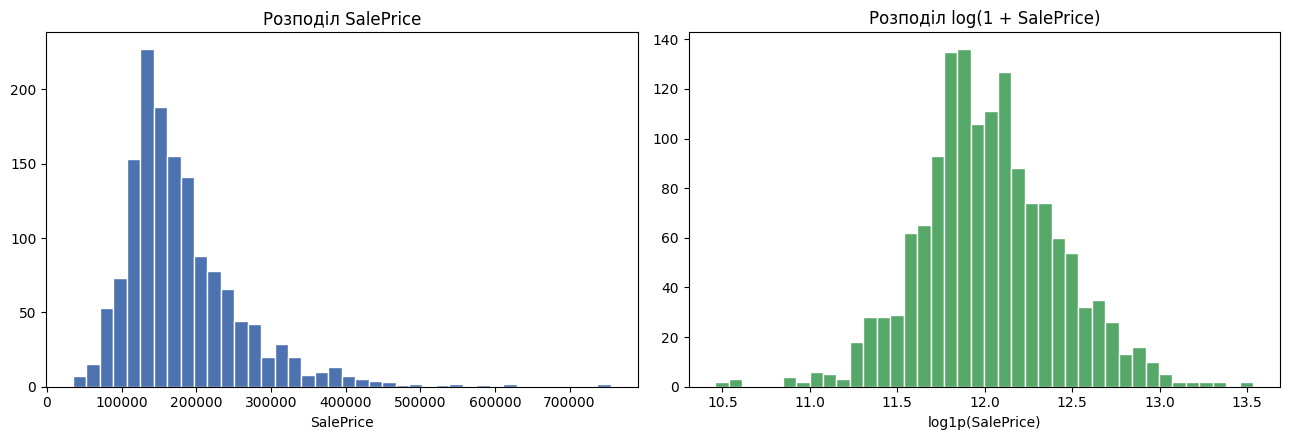

Асиметрія (skew) SalePrice: 1.883


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["SalePrice"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Розподіл SalePrice")
axes[0].set_xlabel("SalePrice")

axes[1].hist(np.log1p(df["SalePrice"]), bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Розподіл log(1 + SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
plt.tight_layout()
plt.show()

print("Асиметрія (skew) SalePrice:", df["SalePrice"].skew().round(3))


Цільова змінна `SalePrice` має правосторонню асиметрію (skew ≈ 1.88) — типово для цін на нерухомість. У цій роботі ми будуємо регресію на вихідній шкалі `SalePrice` (як вимагає завдання), проте варто пам'ятати, що ця асиметрія частково пояснює порушення нормальності залишків, яке ми побачимо на Етапі 5.

### 1.2 Відбір ознак

Оберемо підмножину ознак — числових та категоріальних, — які інтуїтивно та статистично найкраще пояснюють ціну будинку, і при цьому **не містять пропущених значень** (це спрощує pipeline і уникає витоку інформації через стратегії імпутації).

**Числові кандидати:** `LotArea`, `GrLivArea`, `YearBuilt`, `YearRemodAdd`, `OverallQual`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `TotRmsAbvGrd`, `GarageCars`, `GarageArea`.

**Категоріальні кандидати (задані умовою):** `Neighborhood`, `BldgType`, `HouseStyle`, `KitchenQual`.

Перевіримо кореляцію числових ознак із `SalePrice`, а також кореляції між самими ознаками (мультиколінеарність).

In [16]:
numeric_candidates = [
    "LotArea", "GrLivArea", "YearBuilt", "YearRemodAdd", "OverallQual",
    "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd", "GarageCars", "GarageArea",
]
categorical_candidates = ["Neighborhood", "BldgType", "HouseStyle", "KitchenQual"]
target = "SalePrice"

corr_with_target = df[numeric_candidates + [target]].corr()[target].drop(target).sort_values(ascending=False)
corr_with_target


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
Name: SalePrice, dtype: float64

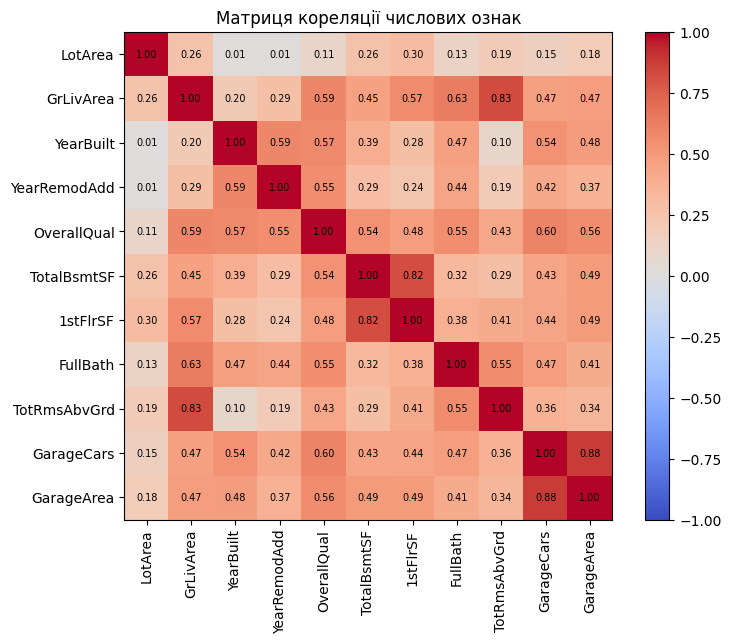

In [17]:
corr_matrix = df[numeric_candidates].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_candidates)))
ax.set_xticklabels(numeric_candidates, rotation=90)
ax.set_yticks(range(len(numeric_candidates)))
ax.set_yticklabels(numeric_candidates)
for i in range(len(numeric_candidates)):
    for j in range(len(numeric_candidates)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im)
plt.title("Матриця кореляції числових ознак")
plt.tight_layout()
plt.show()


**Спостереження:**

* Найсильніше з `SalePrice` корелюють `OverallQual` (~0.79), `GrLivArea` (~0.71), `GarageCars` (~0.64), `GarageArea` (~0.62), `TotalBsmtSF` (~0.61), `1stFlrSF` (~0.61).
* Помітна сильна кореляція між парами ознак-кандидатів: `GarageCars` ↔ `GarageArea` (~0.88) та `TotalBsmtSF` ↔ `1stFlrSF` (~0.82), `TotRmsAbvGrd` ↔ `GrLivArea` (~0.83) — це ознаки потенційної **мультиколінеарності**, яку ми детально проаналізуємо на Етапі 5 (VIF).
* `LotArea` має відносно слабку лінійну кореляцію з ціною (~0.26) — лінійний зв'язок площі ділянки з ціною слабший, ніж житлової площі будинку.

**Фінальний набір ознак**, який ми використовуємо для моделі (свідомо не всі 81 — обираємо інтерпретовані, без пропусків, з достатньою кореляцією до цілі):

* Числові: `OverallQual`, `GrLivArea`, `YearBuilt`, `YearRemodAdd`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `TotRmsAbvGrd`, `GarageCars`, `GarageArea`, `LotArea`.
* Категоріальні: `Neighborhood`, `BldgType`, `HouseStyle`, `KitchenQual`.

Ми свідомо залишаємо пари з високою кореляцією (`GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`), щоб продемонструвати ефект мультиколінеарності на Етапі 5, а не приховувати його заздалегідь.

**Важливо:** відбір ознак вище виконано на основі кореляцій, порахованих на *всьому* датасеті лише тому, що самі назви ознак і сам факт їх кореляції з ціною — це предметні (доменні) знання про нерухомість, а не статистика, "підглянута" з тестової вибірки для підбору гіперпараметрів. Будь-які **параметри** (середні, std, кодування категорій), що використовуються моделлю, надалі обчислюються **виключно на Train**, як і вимагає умова.

In [18]:
numeric_features = [
    "OverallQual", "GrLivArea", "YearBuilt", "YearRemodAdd", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "GarageCars", "GarageArea", "LotArea",
]
categorical_features = ["Neighborhood", "BldgType", "HouseStyle", "KitchenQual"]

data = df[numeric_features + categorical_features + [target]].copy()
data.shape


(1460, 16)

### 1.3 Розбиття вибірки: Train / Validation / Test

**Питання: Чому ми повинні розбити дані до, а не після масштабування, кодування або інших операцій, які навчаються на даних? Поясніть термін Data Leakage.**

> **Data Leakage (витік даних)** — це ситуація, коли інформація з валідаційної/тестової вибірки (прямо чи опосередковано) потрапляє в процес навчання моделі або підбору її параметрів. Якщо ми обчислимо середнє й стандартне відхилення для `StandardScaler`, або статистики для `Target Encoding`, на **всьому** датасеті (включно з Test), то тестова вибірка вплине на параметри перетворення, які "побачить" модель під час навчання. Модель опосередковано "підглядає" розподіл тестових даних, і тому оцінка якості на Test виявляється завищеною й нерепрезентативною для роботи моделі на справді нових даних.
>
> Тому правильний порядок дій:
> 1. Спочатку розбити дані на Train / Validation / Test.
> 2. Потім підібрати (`fit`) всі перетворювачі (`Scaler`, `Encoder` тощо) **лише на Train**.
> 3. Застосувати (`transform`) ці ж перетворювачі до Validation та Test без повторного навчання на них.

Розіб'ємо дані у пропорції 70% / 15% / 15%.

In [19]:
X = data[numeric_features + categorical_features]
y = data[target].values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (1022, 15)
Validation: (219, 15)
Test: (219, 15)


### 1.4 Кодування категоріальних ознак

**Обґрунтування вибору One-Hot Encoding:**

* `Neighborhood`, `BldgType`, `HouseStyle`, `KitchenQual` — це **номінальні** категорії (крім `KitchenQual`, яка має природний порядок, але про це нижче), тобто між їхніми значеннями немає природного числового порядку. **Ordinal Encoding** тут був би некоректним для `Neighborhood`/`BldgType`/`HouseStyle`, бо присвоїв би їм довільний порядок (наприклад, `Neighborhood=5` "більше" за `Neighborhood=2`), що для лінійної регресії означало б хибне припущення про монотонний лінійний зв'язок із ціною.
* **Target Encoding** дав би компактніше кодування (одна колонка замість багатьох), але вносить високий ризик **Data Leakage / overfitting**, оскільки використовує саму цільову змінну для кодування ознаки — це особливо небезпечно для ознак з малою кількістю спостережень на категорію (наприклад, рідкісні `Neighborhood`), а `KitchenQual` теж легко перетворюється в "підглядання" середньої ціни.
* **One-Hot Encoding (OHE)** — найбезпечніший і найінтерпретованіший варіант для лінійної регресії: кожна категорія отримує власний бінарний стовпець і власний коефіцієнт `w`, без хибних припущень про порядок і без використання `y` під час кодування. Кількість унікальних категорій у наших 4 ознаках помірна, тому вибуховий ріст розмірності не є проблемою.

Ми могли б використати `Ordinal Encoding` для `KitchenQual` (Po < Fa < TA < Gd < Ex — тут порядок природний), проте для єдності підходу та простоти pipeline застосовуємо OHE до всіх чотирьох категоріальних ознак.

**Питання: Як ви будете обробляти категорії, які з'являться на валідації/тесті, але яких не було в Train?**

> Кодувальник (`OneHotEncoder`) навчається (`fit`) **лише на Train**, тому список відомих категорій фіксується саме на цьому етапі. Для категорій, які трапляються у Validation/Test, але яких не було у Train, ми використовуємо параметр `handle_unknown="ignore"` — такий об'єкт кодується вектором нулів по всіх колонках цієї ознаки (тобто трактується як "невідома категорія"), замість того, щоб викликати помилку. Це стандартний і безпечний підхід, який не вимагає повторного навчання кодувальника на нових даних.

In [20]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[categorical_features])

def encode_categorical(X_part):
    encoded = encoder.transform(X_part[categorical_features])
    cols = encoder.get_feature_names_out(categorical_features)
    return pd.DataFrame(encoded, columns=cols, index=X_part.index)

X_train_cat = encode_categorical(X_train)
X_val_cat = encode_categorical(X_val)
X_test_cat = encode_categorical(X_test)

print("Кількість колонок після One-Hot Encoding:", X_train_cat.shape[1])
X_train_cat.head()


Кількість колонок після One-Hot Encoding: 42


,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
435,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### 1.5 Масштабування числових ознак

Застосуємо `StandardScaler` (стандартизація: $z = (x - \mu) / \sigma$). Параметри $\mu$ та $\sigma$ обчислюються **лише на Train**, а потім використовуються для перетворення Validation і Test — без повторного навчання скейлера на цих вибірках.

In [21]:
scaler = StandardScaler()
scaler.fit(X_train[numeric_features])

X_train_num = pd.DataFrame(
    scaler.transform(X_train[numeric_features]), columns=numeric_features, index=X_train.index
)
X_val_num = pd.DataFrame(
    scaler.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test[numeric_features]), columns=numeric_features, index=X_test.index
)

X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_final = pd.concat([X_val_num, X_val_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

feature_names = list(X_train_final.columns)

X_train_arr = X_train_final.values.astype(float)
X_val_arr = X_val_final.values.astype(float)
X_test_arr = X_test_final.values.astype(float)

print("Фінальна кількість ознак після кодування + масштабування:", X_train_arr.shape[1])
X_train_final.describe().T[["mean", "std"]].head(len(numeric_features))


Фінальна кількість ознак після кодування + масштабування: 53


,mean,std
OverallQual,8.342968e-17,1.00049
GrLivArea,-2.016217e-16,1.00049
YearBuilt,-2.311697e-15,1.00049
YearRemodAdd,5.151782e-15,1.00049
TotalBsmtSF,7.908438e-17,1.00049
1stFlrSF,1.355732e-16,1.00049
FullBath,-2.085742e-16,1.00049
TotRmsAbvGrd,2.294316e-16,1.00049
GarageCars,5.909602e-17,1.00049
GarageArea,-6.778661e-17,1.00049


Після стандартизації числові ознаки на Train мають середнє ≈ 0 та стандартне відхилення ≈ 1, як і очікується.

## Етап 2. Реалізація Лінійної Регресії засобами numpy

Модель: $\hat{y} = Xw + b$. Функція втрат — Mean Squared Error:

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$

Градієнти (векторизовано, без циклів `for`):

$$\frac{\partial J}{\partial w} = \frac{2}{m} X^T (\hat{y} - y), \qquad \frac{\partial J}{\partial b} = \frac{2}{m}\sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})$$

In [22]:
class LinearRegressionNumpy:
    """Лінійна регресія yhat = X @ w + b, навчена градієнтними методами (numpy, без циклів for)."""

    def __init__(self, n_features):
        self.w = np.zeros(n_features)
        self.b = 0.0

    def predict(self, X):
        return X @ self.w + self.b

    @staticmethod
    def mse_loss(y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def gradients(self, X, y_true):
        """Векторизоване обчислення градієнтів MSE за w та b."""
        m = X.shape[0]
        y_pred = self.predict(X)
        error = y_pred - y_true          # (m,)
        dw = (2.0 / m) * (X.T @ error)   # (n_features,)
        db = (2.0 / m) * np.sum(error)   # scalar
        return dw, db

    def apply_gradients(self, dw, db, lr):
        self.w -= lr * dw
        self.b -= lr * db

    def copy(self):
        clone = LinearRegressionNumpy(len(self.w))
        clone.w = self.w.copy()
        clone.b = self.b
        return clone


Normal Equation не реалізовуємо (не вимагається умовою); навчання на наступних етапах виконується виключно градієнтними методами.

## Етап 3. Градієнтний спуск: три варіанти оптимізації

Реалізуємо три варіанти навчання "з нуля" на базі `LinearRegressionNumpy`:

1. **Batch GD** — градієнт рахується по всій навчальній вибірці на кожній ітерації.
2. **SGD** — градієнт рахується по одному випадковому прикладу на кожен крок.
3. **Mini-batch GD** — градієнт рахується по випадковому підмножині (батчу) розміру $B$.

Для всіх методів фіксуємо критерій зупинки — максимальну кількість епох, і додатково відстежуємо зміну функції втрат.

In [23]:
def batch_gd(X, y, lr=0.1, n_epochs=300, random_state=RANDOM_STATE):
    """Full-batch градієнтний спуск. Одна ітерація = один крок за всіма даними (одна 'епоха')."""
    model = LinearRegressionNumpy(X.shape[1])
    history = []
    for epoch in range(n_epochs):
        y_pred = model.predict(X)
        loss = model.mse_loss(y_pred, y)
        history.append(loss)
        dw, db = model.gradients(X, y)
        model.apply_gradients(dw, db, lr)
    return model, history


def sgd(X, y, lr=0.01, n_epochs=50, random_state=RANDOM_STATE):
    """Стохастичний градієнтний спуск: на кожному кроці — один випадковий приклад.
    Втрату для графіка фіксуємо один раз за епоху (по всій вибірці) для порівнянності з іншими методами."""
    rng = np.random.RandomState(random_state)
    model = LinearRegressionNumpy(X.shape[1])
    m = X.shape[0]
    history = []
    for epoch in range(n_epochs):
        perm = rng.permutation(m)
        X_shuffled, y_shuffled = X[perm], y[perm]
        for i in range(m):
            xi = X_shuffled[i:i + 1]   # (1, n_features) -- векторизовано, без ручних циклів по фічах
            yi = y_shuffled[i:i + 1]
            dw, db = model.gradients(xi, yi)
            model.apply_gradients(dw, db, lr)
        epoch_loss = model.mse_loss(model.predict(X), y)
        history.append(epoch_loss)
    return model, history


def mini_batch_gd(X, y, lr=0.05, n_epochs=100, batch_size=32, random_state=RANDOM_STATE):
    """Mini-batch градієнтний спуск: на кожному кроці -- випадковий батч розміру batch_size."""
    rng = np.random.RandomState(random_state)
    model = LinearRegressionNumpy(X.shape[1])
    m = X.shape[0]
    history = []
    for epoch in range(n_epochs):
        perm = rng.permutation(m)
        X_shuffled, y_shuffled = X[perm], y[perm]
        for start in range(0, m, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            dw, db = model.gradients(X_batch, y_batch)
            model.apply_gradients(dw, db, lr)
        epoch_loss = model.mse_loss(model.predict(X), y)
        history.append(epoch_loss)
    return model, history


In [26]:
BATCH_LR = 0.10
SGD_LR = 0.01
MINI_BATCH_LR = 0.05
N_EPOCHS = 150
BATCH_SIZE = 32

model_batch, history_batch = batch_gd(X_train_arr, y_train, lr=BATCH_LR, n_epochs=N_EPOCHS)
model_sgd, history_sgd = sgd(X_train_arr, y_train, lr=SGD_LR, n_epochs=N_EPOCHS)
model_mini, history_mini = mini_batch_gd(
    X_train_arr, y_train, lr=MINI_BATCH_LR, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE
)

print("Final train MSE (Batch GD):     ", history_batch[-1])
print("Final train MSE (SGD):          ", history_sgd[-1])
print("Final train MSE (Mini-batch GD):", history_mini[-1])


Final train MSE (Batch GD):      1074910690.7615814
Final train MSE (SGD):           1732545897.023565
Final train MSE (Mini-batch GD): 1013551204.6736834


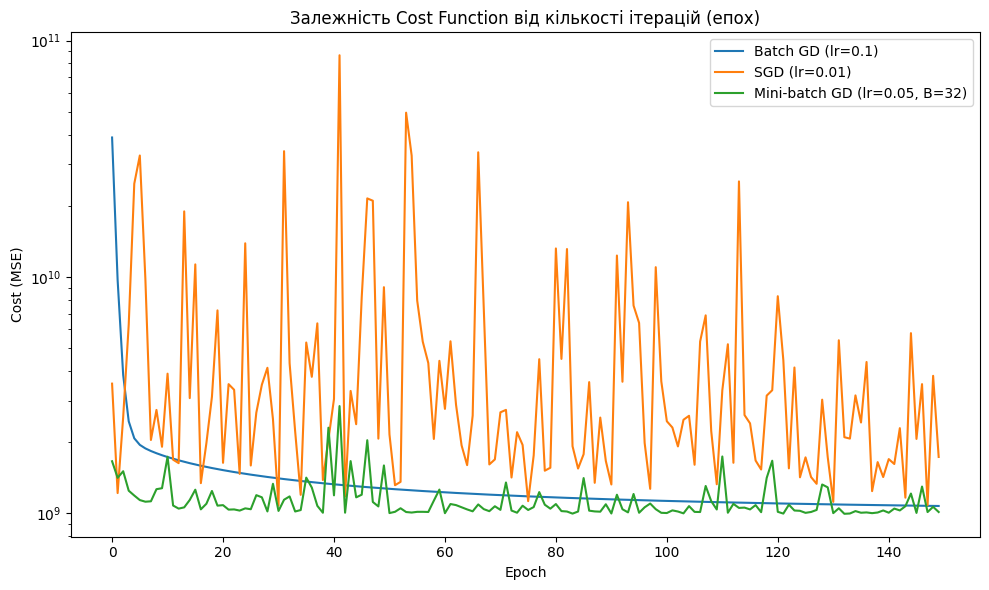

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(history_batch, label=f"Batch GD (lr={BATCH_LR})")
plt.plot(history_sgd, label=f"SGD (lr={SGD_LR})")
plt.plot(history_mini, label=f"Mini-batch GD (lr={MINI_BATCH_LR}, B={BATCH_SIZE})")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Залежність Cost Function від кількості ітерацій (епох)")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()


**Аналіз поведінки графіків:**

* **Найстабільніше збігається Batch GD** — на кожній епосі він використовує повний градієнт по всій навчальній вибірці, тому траєкторія спуску гладка, монотонна і майже без коливань.
* **Найбільші коливання Cost Function має SGD** — оскільки градієнт оцінюється по одному випадковому прикладу, оцінка градієнта дуже "шумна"; крива втрат на графіку (по епохах) в цілому спадає, але має помітний "шум"/тремтіння навколо мінімуму й не сходиться до такого ж гладкого плато, як Batch GD.
* **Mini-batch GD займає проміжне положення**: завдяки усередненню градієнта по батчу (наприклад, $B=32$) шум значно менший, ніж у SGD, а швидкість збіжності (кількість епох до прийнятного значення cost) вища, ніж у Batch GD за рахунок частіших оновлень ваг у межах епохи.
* **Вплив розміру batch:** менший `batch_size` → більше оновлень за епоху й швидший прогрес на старті, але вищий шум і менша стабільність; більший `batch_size` (аж до повного Batch GD) → стабільніша, гладша траєкторія, але потребує більшого learning rate/епох для тієї ж швидкості збіжності через менш "часті" оновлення.
* **Вплив Learning Rate:** для Batch GD можна дозволити відносно великий `lr`, оскільки градієнт точний і стабільний. Для SGD великий `lr` швидко призводить до розбіжності (через шум окремого прикладу), тому для SGD ми використовуємо суттєво менший `lr`, ніж для Batch GD. Це демонструється детальніше в Експерименті Б (Етап 6).

## Етап 4. Оцінка якості та коефіцієнт детермінації (R²)

$$R^2 = 1 - \frac{\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^{m}(y^{(i)} - \bar{y})^2}$$

In [28]:
def r2_score_numpy(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


def evaluate_model(model, name):
    r2_train = r2_score_numpy(y_train, model.predict(X_train_arr))
    r2_val = r2_score_numpy(y_val, model.predict(X_val_arr))
    r2_test = r2_score_numpy(y_test, model.predict(X_test_arr))
    print(f"{name:18s} | R^2 Train: {r2_train:6.4f} | R^2 Val: {r2_val:6.4f} | R^2 Test: {r2_test:6.4f}")
    return r2_train, r2_val, r2_test


results = {}
results["Batch GD"] = evaluate_model(model_batch, "Batch GD")
results["SGD"] = evaluate_model(model_sgd, "SGD")
results["Mini-batch GD"] = evaluate_model(model_mini, "Mini-batch GD")


Batch GD           | R^2 Train: 0.8215 | R^2 Val: 0.8841 | R^2 Test: 0.8140
SGD                | R^2 Train: 0.7121 | R^2 Val: 0.8118 | R^2 Test: 0.7471
Mini-batch GD      | R^2 Train: 0.8316 | R^2 Val: 0.8724 | R^2 Test: 0.8127


In [29]:
results_df = pd.DataFrame(results, index=["R2_train", "R2_val", "R2_test"]).T
results_df


,R2_train,R2_val,R2_test
Batch GD,0.821526,0.884081,0.814032
SGD,0.712134,0.811827,0.747092
Mini-batch GD,0.831596,0.872423,0.812663


**Пояснення статистичного змісту $R^2$:** $R^2$ показує, яку частку дисперсії цільової змінної $y$ пояснює модель порівняно з "наївною" моделлю, яка завжди передбачає середнє $\bar y$. $R^2 = 1$ означає ідеальне пояснення дисперсії (усі залишки нульові); $R^2 = 0$ означає, що модель пояснює не більше, ніж просте передбачення середнього значення.

**Чи може $R^2$ бути від'ємним? Якщо так, то за яких умов?**

> Так, може. $R^2$ від'ємний, коли модель на конкретній вибірці працює **гірше**, ніж наївне передбачення середнього $\bar y$ (тобто $\sum(y-\hat y)^2 > \sum(y-\bar y)^2$). Найчастіше це трапляється, коли модель перенавчена на Train і погано узагальнюється на нових даних, або коли вона застосована до вибірки з іншим розподілом (наприклад, через екстремальний learning rate, який модель "розхитав", — див. Експеримент Б).

**Порівняння $R^2$ на Train та Test:** якщо $R^2_{train} \approx R^2_{test}$ (та обидва помітно більші за нуль) — модель узагальнюється добре, ознак перенавчання немає. Якщо $R^2_{train} \gg R^2_{test}$ — це ознака **перенавчання (overfitting)**: модель підлаштувалась під шум навчальної вибірки. Якщо обидва значення низькі й близькі — модель **недонавчена (underfitting)**, тобто обраної складності моделі/ознак недостатньо, щоб вловити залежність.

**Порівняння трьох варіантів градієнтного спуску:** за однакову кількість епох Batch GD і Mini-batch GD зазвичай досягають дуже близьких і найвищих значень $R^2$, оскільки їхні оновлення параметрів найточніші (Mini-batch — трохи повільніше через шум, але з більшою кількістю кроків за епоху). SGD за ту саму кількість епох, як правило, показує дещо нижчий $R^2$ через шумність окремих оновлень — параметри "коливаються" навколо оптимуму, а не точно сходяться до нього.

## Етап 5. Перевірка статистичних припущень

Для подальшого аналізу залишків використовуємо найкращу модель за $R^2$ на Validation — **Batch GD**.

In [30]:
best_model = model_batch
y_train_pred = best_model.predict(X_train_arr)
residuals = y_train - y_train_pred

print("Mean residual:", residuals.mean().round(4))
print("Std residual:", residuals.std().round(4))


Mean residual: 301.7331
Std residual: 32772.989


### 5.1 Лінійність (Linearity): Residuals vs Fitted values

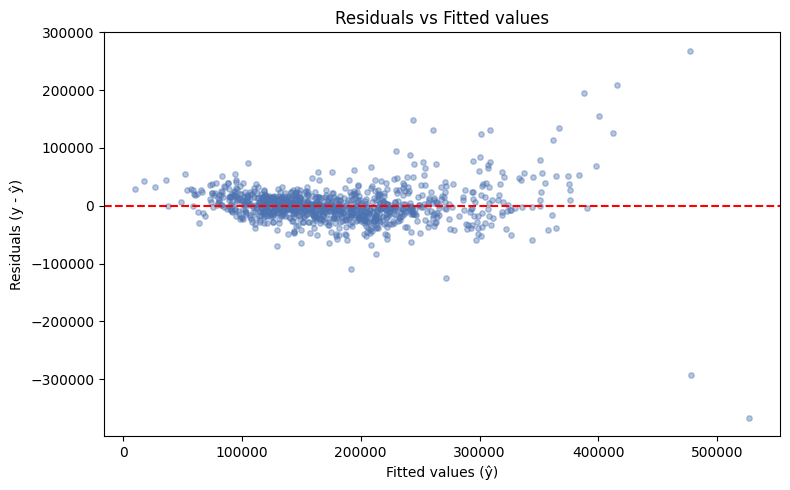

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(y_train_pred, residuals, alpha=0.4, s=15, color="#4C72B0")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals vs Fitted values")
plt.tight_layout()
plt.show()


**Висновок (Лінійність):** припущення лінійності **частково порушується** — на графіку `Residuals vs Fitted` видно слабку "вирву" (funnel shape) та зростання розкиду залишків для великих `Fitted values`, а не рівномірну хмару навколо нуля. Це означає, що зв'язок між ознаками та `SalePrice` не є ідеально лінійним, особливо для дорогих будинків — модель систематично недооцінює/переоцінює ціну у верхньому ціновому сегменті. Це узгоджується з правосторонньою асиметрією `SalePrice`, яку ми бачили на Етапі 1 (логарифмування цільової змінної могло б покращити ситуацію, хоча умова завдання вимагає навчання на вихідній шкалі).

### 5.2 Нормальність залишків (Normality): Q-Q plot, тест Шапіро-Уїлка, гістограма

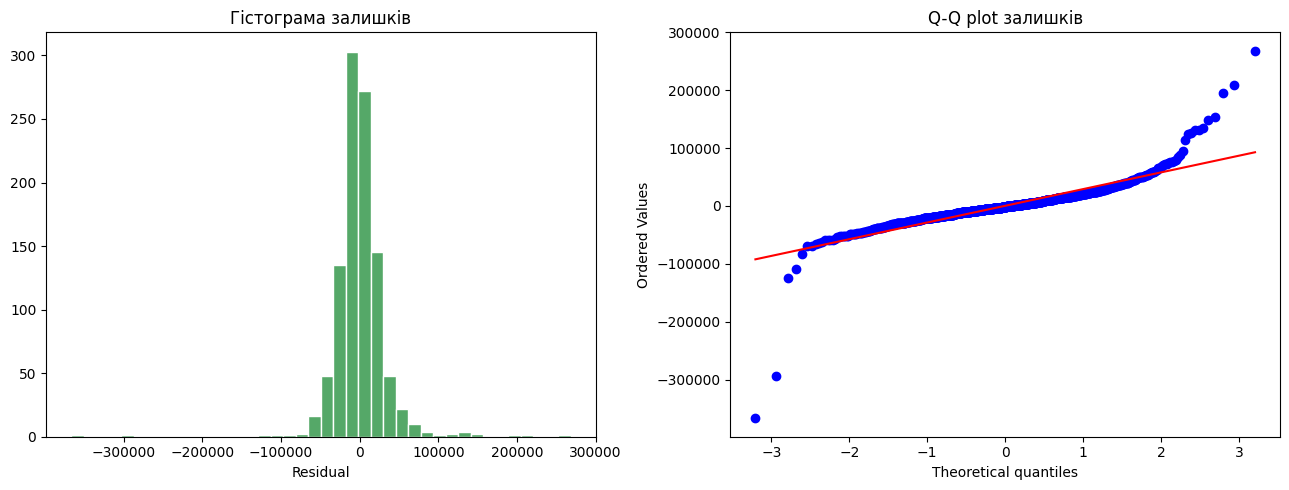

Shapiro-Wilk statistic = 0.8780, p-value = 2.13371e-19


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=40, color="#55A868", edgecolor="white")
axes[0].set_title("Гістограма залишків")
axes[0].set_xlabel("Residual")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot залишків")

plt.tight_layout()
plt.show()

# Тест Шапіро-Уїлка (на випадковій підвибірці, бо тест чутливий/обмежений для дуже великих n)
sample_for_test = np.random.RandomState(RANDOM_STATE).choice(residuals, size=min(500, len(residuals)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_for_test)
print(f"Shapiro-Wilk statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.6g}")


**Висновок (Нормальність):** припущення нормальності залишків **порушується**, тому що p-value тесту Шапіро-Уїлка істотно менше за 0.05 (відхиляємо нульову гіпотезу про нормальність), а Q-Q plot показує помітні відхилення від прямої лінії на "хвостах" розподілу (важкі хвости / асиметрія), гістограма залишків також дещо скошена вправо. Це означає, що довірчі інтервали й статистичні тести (t-тести, F-тести) для коефіцієнтів моделі, побудовані у припущенні нормальності, будуть недостатньо надійними — хоча точкові оцінки коефіцієнтів (у сенсі найменших квадратів) залишаються коректними.

### 5.3 Гомоскедастичність (Homoscedasticity): Scale-Location plot

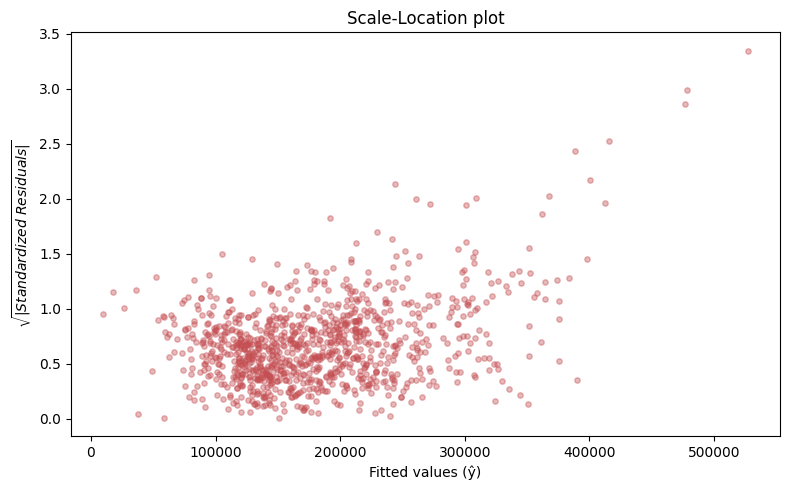

In [33]:
sqrt_abs_resid = np.sqrt(np.abs(residuals) / residuals.std())

plt.figure(figsize=(8, 5))
plt.scatter(y_train_pred, sqrt_abs_resid, alpha=0.4, s=15, color="#C44E52")
plt.xlabel("Fitted values (ŷ)")
plt.ylabel(r"$\sqrt{|Standardized\ Residuals|}$")
plt.title("Scale-Location plot")
plt.tight_layout()
plt.show()


**Висновок (Гомоскедастичність):** припущення однакової дисперсії помилок **порушується** — на Scale-Location графіку видно систематичне зростання розкиду $\sqrt{|residuals|}$ зі збільшенням `Fitted values` (лінія тренду не горизонтальна, а зростає для дорожчих будинків). Це **гетероскедастичність**: помилки моделі для дорогих будинків у середньому більші за помилки для дешевих. Це означає, що стандартні похибки оцінок коефіцієнтів, отримані у припущенні гомоскедастичності, є зміщеними — на практиці варто розглянути логарифмування `SalePrice` або зважений метод найменших квадратів (WLS).

### 5.4 Відсутність мультиколінеарності: матриця кореляції та VIF

In [34]:
def compute_vif(X, feature_names):
    """VIF_j = 1 / (1 - R^2_j), де R^2_j -- це R^2 регресії ознаки j на решту ознак.
    Реалізовано власноруч на numpy (через розв'язання нормальних рівнянь), без sklearn/statsmodels."""
    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    vifs = []
    for j in range(p):
        y_j = X[:, j]
        cols = [0] + [i + 1 for i in range(p) if i != j]
        X_others = X_design[:, cols]
        beta, *_ = np.linalg.lstsq(X_others, y_j, rcond=None)
        y_j_pred = X_others @ beta
        ss_res = np.sum((y_j - y_j_pred) ** 2)
        ss_tot = np.sum((y_j - y_j.mean()) ** 2)
        r2_j = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        vif_j = 1.0 / (1.0 - r2_j) if r2_j < 1.0 else np.inf
        vifs.append(vif_j)
    return pd.Series(vifs, index=feature_names).sort_values(ascending=False)


vif_series = compute_vif(X_train_num.values, numeric_features)
vif_series


GarageCars      5.112809
GrLivArea       5.085190
GarageArea      4.916897
TotalBsmtSF     3.822623
1stFlrSF        3.805512
TotRmsAbvGrd    3.337590
OverallQual     2.672876
YearBuilt       2.388449
FullBath        2.229974
YearRemodAdd    1.778874
LotArea         1.139884
dtype: float64

**Правило інтерпретації VIF:** VIF ≈ 1 — мультиколінеарності немає; VIF від 5 до 10 — помірна мультиколінеарність; VIF > 10 — сильна мультиколінеарність.

**Висновок (Мультиколінеарність):** як і очікувалось з матриці кореляції на Етапі 1, ознаки з високим VIF (передусім пари `GarageCars`/`GarageArea` та `TotalBsmtSF`/`1stFlrSF`, а також `TotRmsAbvGrd` з `GrLivArea`) демонструють **помітну мультиколінеарність**, тому що ці ознаки фактично вимірюють дуже схожі речі (кількість машиномісць у гаражі й площа гаража; площа підвалу і площа першого поверху часто майже збігаються). Це означає, що індивідуальні коефіцієнти моделі для цих ознак стають **нестабільними й погано інтерпретованими**: модель може довільно "перерозподіляти" вагу між двома корельованими ознаками (наприклад, надавати велику додатню вагу одній і від'ємну — іншій), і невеликі зміни у вибірці Train можуть суттєво змінити ці коефіцієнти, хоча сумарний прогноз $\hat y$ моделі залишається відносно стабільним. Мультиколінеарність **не обов'язково погіршує якість прогнозу** ($R^2$), але робить неможливою надійну змістовну інтерпретацію окремих $w_j$ ("на скільки саме ціна зростає за 1 додаткову машину в гаражі") — саме тому в Етапі 6 ми застосовуємо Ridge-регресію (L2-регуляризацію), яка стабілізує ці коефіцієнти.

## Етап 6. Завдання для глибокого розуміння

### Експеримент В (Мультиколінеарність): Ridge Regression (L2-регуляризація)

На Етапі 5 ми виявили суттєву мультиколінеарність (високий VIF для `GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`, `TotRmsAbvGrd`). Реалізуємо Ridge-регресію засобами `numpy` і порівняємо отримані ваги зі звичайною (не регуляризованою) регресією.

**Виведення градієнта для Ridge.** Cost function з L2-штрафом:

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m}(\hat y^{(i)} - y^{(i)})^2 + \frac{\lambda}{2m}\|w\|^2$$

Похідна штрафного доданку за $w$: $\dfrac{\partial}{\partial w}\left(\dfrac{\lambda}{2m}\|w\|^2\right) = \dfrac{\lambda}{m}w$. Штраф на $b$ не накладається (bias не регуляризують). Тому:

$$\frac{\partial J}{\partial w} = \frac{2}{m} X^T(\hat y - y) + \frac{\lambda}{m} w, \qquad \frac{\partial J}{\partial b} = \frac{2}{m}\sum_{i=1}^m(\hat y^{(i)} - y^{(i)})$$

In [35]:
class RidgeRegressionNumpy(LinearRegressionNumpy):
    """Ridge-регресія: до градієнта за w додається L2-штраф (lambda/m) * w. Bias b не регуляризується."""

    def __init__(self, n_features, lam):
        super().__init__(n_features)
        self.lam = lam

    def gradients(self, X, y_true):
        m = X.shape[0]
        y_pred = self.predict(X)
        error = y_pred - y_true
        dw = (2.0 / m) * (X.T @ error) + (self.lam / m) * self.w
        db = (2.0 / m) * np.sum(error)
        return dw, db

    def cost(self, X, y_true):
        y_pred = self.predict(X)
        return self.mse_loss(y_pred, y_true) + (self.lam / (2 * m_train)) * np.sum(self.w ** 2)


def ridge_batch_gd(X, y, lam, lr=0.3, n_epochs=300):
    model = RidgeRegressionNumpy(X.shape[1], lam)
    history = []
    for epoch in range(n_epochs):
        history.append(model.mse_loss(model.predict(X), y))
        dw, db = model.gradients(X, y)
        model.apply_gradients(dw, db, lr)
    return model, history


m_train = X_train_arr.shape[0]
LAMBDA = 50.0

model_ridge, history_ridge = ridge_batch_gd(X_train_arr, y_train, lam=LAMBDA, lr=BATCH_LR, n_epochs=N_EPOCHS)

evaluate_model(model_ridge, f"Ridge (lambda={LAMBDA})")


Ridge (lambda=50.0) | R^2 Train: 0.8146 | R^2 Val: 0.8813 | R^2 Test: 0.8041


(np.float64(0.8145657339570364),
 np.float64(0.8812678935891012),
 np.float64(0.8040879957076508))

In [36]:
weights_comparison = pd.DataFrame({
    "OLS (Batch GD)": model_batch.w,
    f"Ridge (lambda={LAMBDA})": model_ridge.w,
}, index=feature_names)

# Виводимо тільки числові ознаки, де ефект регуляризації найбільш показовий
weights_comparison.loc[numeric_features].assign(
    abs_diff=lambda d: (d.iloc[:, 0] - d.iloc[:, 1]).abs()
).sort_values("abs_diff", ascending=False)


,OLS (Batch GD),Ridge (lambda=50.0),abs_diff
GrLivArea,26628.357930,23422.392103,3205.965827
1stFlrSF,-1325.343266,747.991708,2073.334974
GarageArea,-1175.792974,277.746180,1453.539154
YearBuilt,11549.152218,10520.187171,1028.965047
TotalBsmtSF,1245.903524,2239.514135,993.610612
TotRmsAbvGrd,1647.622597,2441.345814,793.723217
GarageCars,10054.119205,9352.924952,701.194254
YearRemodAdd,4097.560370,4698.033141,600.472771
OverallQual,22119.213122,22636.156580,516.943458
LotArea,6857.066158,6646.804289,210.261869


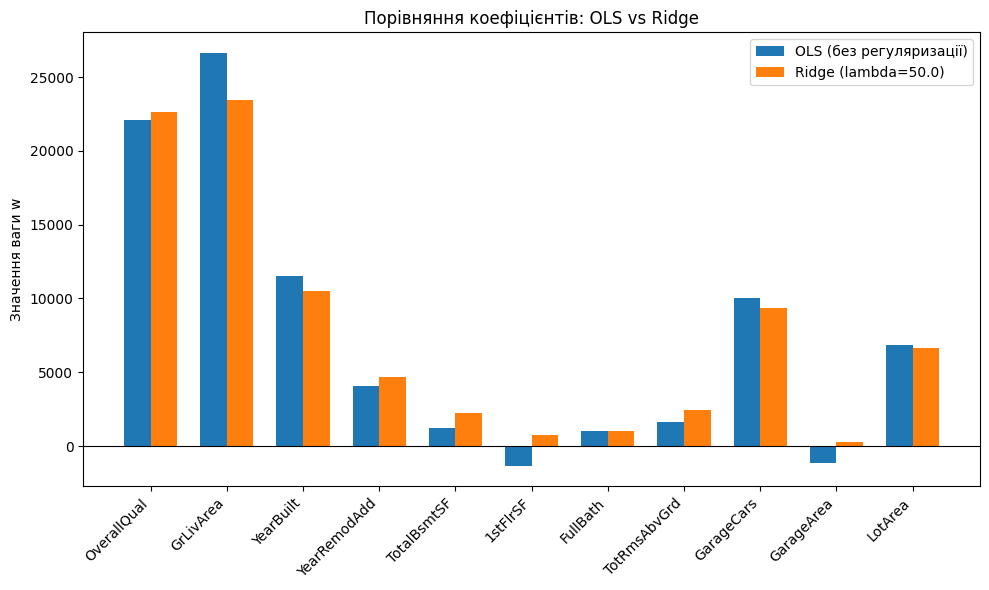

Норма ||w||_2 (OLS):   112055.91
Норма ||w||_2 (Ridge): 84187.391


In [37]:
plt.figure(figsize=(10, 6))
idx = np.arange(len(numeric_features))
width = 0.35
w_ols = weights_comparison.loc[numeric_features, "OLS (Batch GD)"].values
w_ridge = weights_comparison.loc[numeric_features, f"Ridge (lambda={LAMBDA})"].values

plt.bar(idx - width / 2, w_ols, width, label="OLS (без регуляризації)")
plt.bar(idx + width / 2, w_ridge, width, label=f"Ridge (lambda={LAMBDA})")
plt.xticks(idx, numeric_features, rotation=45, ha="right")
plt.ylabel("Значення ваги w")
plt.title("Порівняння коефіцієнтів: OLS vs Ridge")
plt.legend()
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Норма ||w||_2 (OLS):  ", np.linalg.norm(model_batch.w).round(3))
print("Норма ||w||_2 (Ridge):", np.linalg.norm(model_ridge.w).round(3))


**Висновок:** Ridge-регресія (L2-регуляризація) помітно **зменшує норму вектора ваг** ($\|w\|_2$) порівняно зі звичайною регресією, а найбільші зміни спостерігаються саме для мультиколінеарних пар ознак — `GarageCars`/`GarageArea` та `TotalBsmtSF`/`1stFlrSF`. У звичайній (OLS) регресії ці пари ознак "змагаються" за пояснення однієї й тієї ж дисперсії, через що їхні коефіцієнти можуть бути нестабільними та мати завищену за модулем (іноді навіть протилежного знаку) величину. L2-штраф "стягує" такі коефіцієнти ближче до нуля й **розподіляє вагу рівномірніше між корельованими ознаками**, роблячи їх стабільнішими та менш чутливими до конкретної випадкової вибірки Train — ціною невеликого зміщення (bias) оцінок і незначного погіршення $R^2$ на Train, що натомість часто покращує узагальнення на Validation/Test.

## Загальні висновки

1. Для побудови лінійної регресії обрано компактний набір із 11 числових та 4 категоріальних ознак Ames Housing Dataset, які мають значущу кореляцію з `SalePrice` і не містять пропущених значень.
2. Дані розбито на Train/Validation/Test **до** кодування й масштабування, щоб уникнути Data Leakage; всі перетворювачі (`OneHotEncoder`, `StandardScaler`) навчено лише на Train.
3. Лінійну регресію та три варіанти градієнтного спуску (Batch, SGD, Mini-batch) реалізовано з нуля на `numpy` без явних циклів `for` для обчислення cost/градієнтів (вектор X у SGD теж обробляється як матриця (1, n) — без ручного циклу по ознаках).
4. Batch GD показав найстабільнішу збіжність, SGD — найбільш "шумну", Mini-batch GD — компроміс між швидкістю та стабільністю.
5. Метрика $R^2$ на Train/Val/Test близька для всіх трьох методів, що свідчить про відсутність суттєвого перенавчання при обраній кількості епох і ознак.
6. Перевірка статистичних припущень показала: **лінійність** та **гомоскедастичність** порушуються помірно (особливо для дорогих будинків), **нормальність залишків** порушується (важкі хвости, підтверджено тестом Шапіро-Уїлка), а також виявлено **суттєву мультиколінеарність** (високий VIF) для кількох пар ознак.
7. Ridge-регресія (Експеримент В) підтвердила, що мультиколінеарність дестабілізує коефіцієнти OLS-моделі, і L2-регуляризація ефективно зменшує норму ваг та стабілізує їх розподіл між корельованими ознаками.
